In [18]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=GROQ_API_KEY)

In [19]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
        a: first int
        b: second int
    """
    return a * b


def add(a: int, b: int) -> int:
    """
    Add a and b

    Args:
        a: first int
        b: second int
    """
    return a + b


def divide(a: int, b: int) -> int:
    """
    Divide a and b

    Args:
        a: first int
        b: second int
    """
    return a / b

In [20]:
tools = [add, divide, multiply]

In [21]:
llm_with_tools = llm.bind_tools(tools=tools)

In [22]:
from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [23]:
system_msg = SystemMessage(
    content="You are a helpful assistant tasked with performing arithmatic on a set of inputs."
)

In [24]:
def assistant(state: MessagesState):
    return {"messages": llm_with_tools.invoke([system_msg] + state["messages"])}

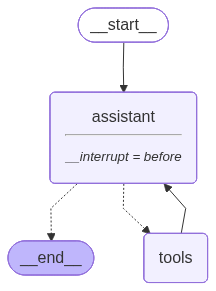

In [25]:
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

memory = MemorySaver()

graph = builder.compile(checkpointer=memory, interrupt_before=["assistant"])

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
thread = {"configurable": {"thread_id": "123"}}

initial_input = {"messages": [HumanMessage(content="Multiply 2 and 3")]}

### Interrupt for Human Feedback


In [27]:
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [28]:
state = graph.get_state(thread)
state.next

('assistant',)

In [29]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (2ejfes9ag)
 Call ID: 2ejfes9ag
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [30]:
state = graph.get_state(thread)
state.next

('assistant',)

In [31]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [32]:
state = graph.get_state(thread)
state.next

()

### Edit Human Feedback


In [33]:
thread = {"configurable": {"thread_id": "234"}}
initial_input = {"messages": [HumanMessage(content="Multiply 2 and 3")]}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [34]:
state = graph.get_state(thread)
state.next

('assistant',)

In [36]:
graph.update_state(
    thread, {"messages": [HumanMessage(content="Please multiply 15 and 6")]}
)

{'configurable': {'thread_id': '234',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14b790-7a9b-6d31-8001-9ea72f780ee9'}}

In [37]:
new_state = graph.get_state(thread).values
for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

Please multiply 15 and 6


In [38]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (z4ebp3v0t)
 Call ID: z4ebp3v0t
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [39]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

The result of multiplying 15 and 6 is 90.


### Wait for user input


In [40]:
def human_feedback(state: MessagesState):
    pass

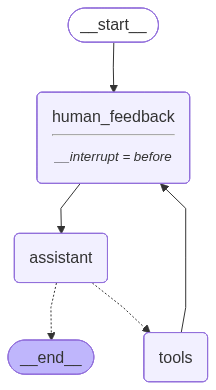

In [41]:
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=["human_feedback"])
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
thread = {"configurable": {"thread_id": "789"}}
initial_input = {"messages": [HumanMessage(content="Multiply 2 and 3")]}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

user_input = input("Tell me how you want to update the state: ")
graph.update_state(thread, {'messages' : user_input}, as_node="human_feedback")

for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

Add 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (k43k937e5)
 Call ID: k43k937e5
  Args:
    a: 2
    b: 3
  add (7t5gc040m)
 Call ID: 7t5gc040m
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: add

11


In [46]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: add

11
================================== Ai Message ==================================

The results of the operations are:
- 2 * 3 = 6
- 5 + 6 = 11
